In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import re

# Display & style settings
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [85]:
master = pd.read_csv(
    'data/output/master_table.csv',
    parse_dates=['order_date', 'signup_date'],
    low_memory=False
)

print(f"master_table loaded: {len(master):,} rows × {master.shape[1]} columns")
print(f"Thời gian: {master['order_date'].min().date()} → {master['order_date'].max().date()}")
master.head(3)

master_table loaded: 714,669 rows × 53 columns
Thời gian: 2012-07-04 → 2022-12-31


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,order_item_id,line_revenue,order_date,...,promo_channel,min_order_value,stock_on_hand,fill_rate,sell_through_rate,stockout_flag,stockout_days,line_cogs,is_legacy,category_return_prob
0,1,2400,7,"1,138.22",0.00,NO_PROMO,NO_PROMO,1_2400,"7,967.54",2012-07-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"7,376.59",1,0.06
1,2,609,7,"10,166.25",0.00,NO_PROMO,NO_PROMO,2_609,"71,163.75",2012-07-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"62,913.93",1,0.06
2,3,396,3,"11,220.33",0.00,NO_PROMO,NO_PROMO,3_396,"33,660.99",2012-07-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"30,273.04",1,0.06


In [87]:
# ══════════════════════════════════════════════════════════════════════════
# STEP 0 — Data Preparation
#   master_table: 1 row per order_item → aggregate to 1 row per order
#   Also parse product_name into brand / model_code / product_num
# ══════════════════════════════════════════════════════════════════════════

# ── Order-level aggregation ───────────────────────────────────────────────
order_level = (
    master.groupby('order_id', as_index=False)
    .agg(
        customer_id   = ('customer_id',  'first'),
        order_date    = ('order_date',   'first'),
        order_source  = ('order_source', 'first'),
        order_revenue = ('line_revenue', 'sum'),
    )
)

# Rank each customer's orders chronologically (1 = first ever order)
order_level = order_level.sort_values(['customer_id', 'order_date'])
order_level['order_rank'] = order_level.groupby('customer_id').cumcount() + 1
order_level['customer_type'] = np.where(
    order_level['order_rank'] == 1, 'New Customer', 'Returning Customer'
)

# ── Parse product_name → brand / model_code / product_num ────────────────
# Pattern: "VietMode RP-44" → brand="VietMode", model_code="RP", product_num="44"
def _parse_product(name):
    m = re.match(r'^(.+?)\s+([A-Z]+)-(\d+)$', str(name))
    return (m.group(1), m.group(2), m.group(3)) if m else (name, None, None)

_parsed = master['product_name'].apply(_parse_product)
master['brand']       = _parsed.apply(lambda t: t[0])
master['model_code']  = _parsed.apply(lambda t: t[1])
master['product_num'] = _parsed.apply(lambda t: t[2])

# ── Merge order_rank into master for item-level analyses ─────────────────
master_with_rank = master.merge(
    order_level[['order_id', 'order_rank', 'customer_type']],
    on='order_id', how='left'
)

# Subset: rows belonging to repeat orders (rank ≥ 2)
repeat_items = master_with_rank[master_with_rank['order_rank'] > 1].copy()

# ── Sanity checks ─────────────────────────────────────────────────────────
n_unique_orders   = len(order_level)
n_first           = (order_level['order_rank'] == 1).sum()
n_repeat          = (order_level['order_rank'] >  1).sum()
n_unique_custs    = order_level['customer_id'].nunique()
n_retained_custs  = order_level[order_level['order_rank'] > 1]['customer_id'].nunique()

print(f"Unique orders             : {n_unique_orders:,}")
print(f"First orders  (New)       : {n_first:,}")
print(f"Repeat orders (Returning) : {n_repeat:,}")
print(f"Unique customers          : {n_unique_custs:,}")
print(f"Retained customers (≥2 ord): {n_retained_custs:,}")
print(f"Overall retention rate     : {n_retained_custs / n_unique_custs * 100:.1f}%")
print(f"\nProduct name parse check  : {master['brand'].notna().sum():,} / {len(master):,} parsed OK")
print(f"Unique brands found       : {master['brand'].nunique()}")

Unique orders             : 646,945
First orders  (New)       : 90,246
Repeat orders (Returning) : 556,699
Unique customers          : 90,246
Retained customers (≥2 ord): 67,888
Overall retention rate     : 75.2%

Product name parse check  : 714,669 / 714,669 parsed OK
Unique brands found       : 14


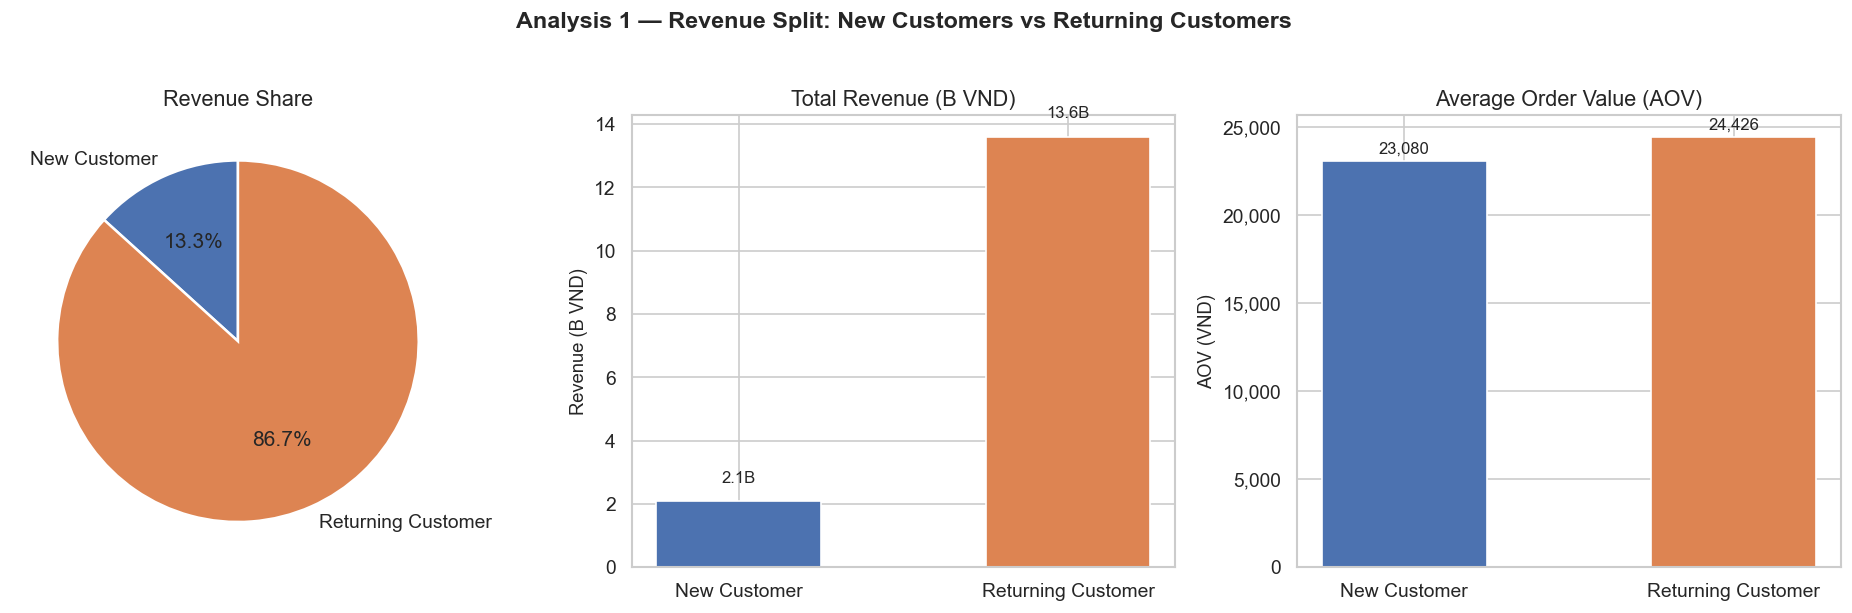


── Revenue Summary ──────────────────────────────────────────────────────
     customer_type     total_revenue  order_count  avg_order_value  revenue_share_pct
      New Customer  2,082,833,213.51        90246        23,079.51              13.28
Returning Customer 13,598,036,051.92       556699        24,426.19              86.72


In [88]:
# ══════════════════════════════════════════════════════════════════════════
# ANALYSIS 1 — Revenue Split: New Customers vs Returning Customers
# ══════════════════════════════════════════════════════════════════════════

rev_by_type = (
    order_level.groupby('customer_type')['order_revenue']
    .agg(total_revenue='sum', order_count='count', avg_order_value='mean')
    .reset_index()
)
rev_by_type['revenue_share_pct'] = (
    rev_by_type['total_revenue'] / rev_by_type['total_revenue'].sum() * 100
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Analysis 1 — Revenue Split: New Customers vs Returning Customers',
             fontsize=14, fontweight='bold', y=1.02)

wedge_colors = ['#4C72B0', '#DD8452']

# (a) Revenue share — pie
axes[0].pie(
    rev_by_type['total_revenue'],
    labels=rev_by_type['customer_type'],
    autopct='%1.1f%%',
    colors=wedge_colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('Revenue Share')

# (b) Total revenue — bar
bars = axes[1].bar(
    rev_by_type['customer_type'],
    rev_by_type['total_revenue'] / 1e9,
    color=wedge_colors, edgecolor='white', width=0.5
)
for bar, val in zip(bars, rev_by_type['total_revenue']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.5,
                 f'{val/1e9:,.1f}B', ha='center', va='bottom', fontsize=10)
axes[1].set_title('Total Revenue (B VND)')
axes[1].set_ylabel('Revenue (B VND)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# (c) Average order value — bar
bars2 = axes[2].bar(
    rev_by_type['customer_type'],
    rev_by_type['avg_order_value'],
    color=wedge_colors, edgecolor='white', width=0.5
)
for bar, val in zip(bars2, rev_by_type['avg_order_value']):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + rev_by_type['avg_order_value'].max() * 0.01,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=10)
axes[2].set_title('Average Order Value (AOV)')
axes[2].set_ylabel('AOV (VND)')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

print("\n── Revenue Summary ──────────────────────────────────────────────────────")
print(rev_by_type[['customer_type', 'total_revenue', 'order_count',
                    'avg_order_value', 'revenue_share_pct']]
      .to_string(index=False))

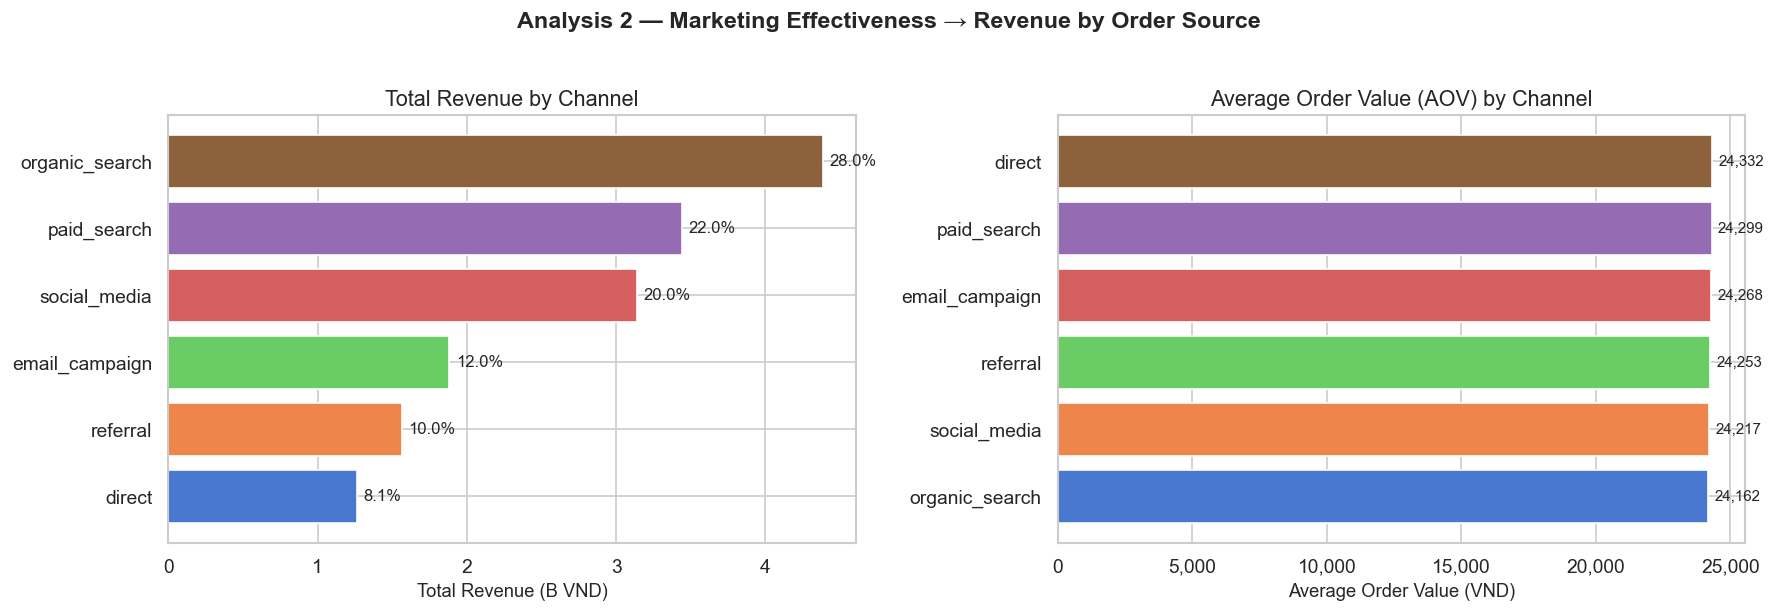


── Marketing → Revenue Summary ──────────────────────────────────────────
  order_source    total_revenue  order_count  avg_order_value  revenue_share_pct
organic_search 4,385,324,881.54       181495        24,162.24              27.97
   paid_search 3,441,964,418.44       141652        24,298.74              21.95
  social_media 3,141,153,470.29       129710        24,216.74              20.03
email_campaign 1,882,479,280.82        77572        24,267.51              12.00
      referral 1,565,897,314.00        64565        24,253.04               9.99
        direct 1,264,049,900.34        51951        24,331.58               8.06


In [90]:
# ══════════════════════════════════════════════════════════════════════════
# ANALYSIS 2 — Marketing Effectiveness → Revenue by Order Source
# ══════════════════════════════════════════════════════════════════════════

src_rev = (
    order_level.groupby('order_source')
    .agg(
        total_revenue   = ('order_revenue', 'sum'),
        order_count     = ('order_id',      'count'),
        avg_order_value = ('order_revenue', 'mean'),
    )
    .reset_index()
    .sort_values('total_revenue', ascending=True)   # ascending → largest bar at top in barh
)
src_rev['revenue_share_pct'] = (
    src_rev['total_revenue'] / src_rev['total_revenue'].sum() * 100
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Analysis 2 — Marketing Effectiveness → Revenue by Order Source',
             fontsize=14, fontweight='bold', y=1.02)

palette = sns.color_palette('muted', len(src_rev))

# (a) Total revenue per source
bars = axes[0].barh(
    src_rev['order_source'],
    src_rev['total_revenue'] / 1e9,
    color=palette, edgecolor='white'
)
for bar, pct in zip(bars, src_rev['revenue_share_pct']):   # same order as bars
    axes[0].text(bar.get_width() + src_rev['total_revenue'].max() / 1e9 * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f'{pct:.1f}%', va='center', fontsize=10)
axes[0].set_xlabel('Total Revenue (B VND)')
axes[0].set_title('Total Revenue by Channel')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# (b) Average order value per source — sorted descending by AOV (largest at top)
src_rev_aov = src_rev.sort_values('avg_order_value', ascending=True)
bars2 = axes[1].barh(
    src_rev_aov['order_source'],
    src_rev_aov['avg_order_value'],
    color=palette, edgecolor='white'
)
for bar, val in zip(bars2, src_rev_aov['avg_order_value']):
    axes[1].text(bar.get_width() + src_rev_aov['avg_order_value'].max() * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:,.0f}', va='center', fontsize=9)
axes[1].set_xlabel('Average Order Value (VND)')
axes[1].set_title('Average Order Value (AOV) by Channel')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

print("\n── Marketing → Revenue Summary ──────────────────────────────────────────")
print(src_rev.sort_values('total_revenue', ascending=False)
      [['order_source', 'total_revenue', 'order_count',
        'avg_order_value', 'revenue_share_pct']]
      .to_string(index=False))

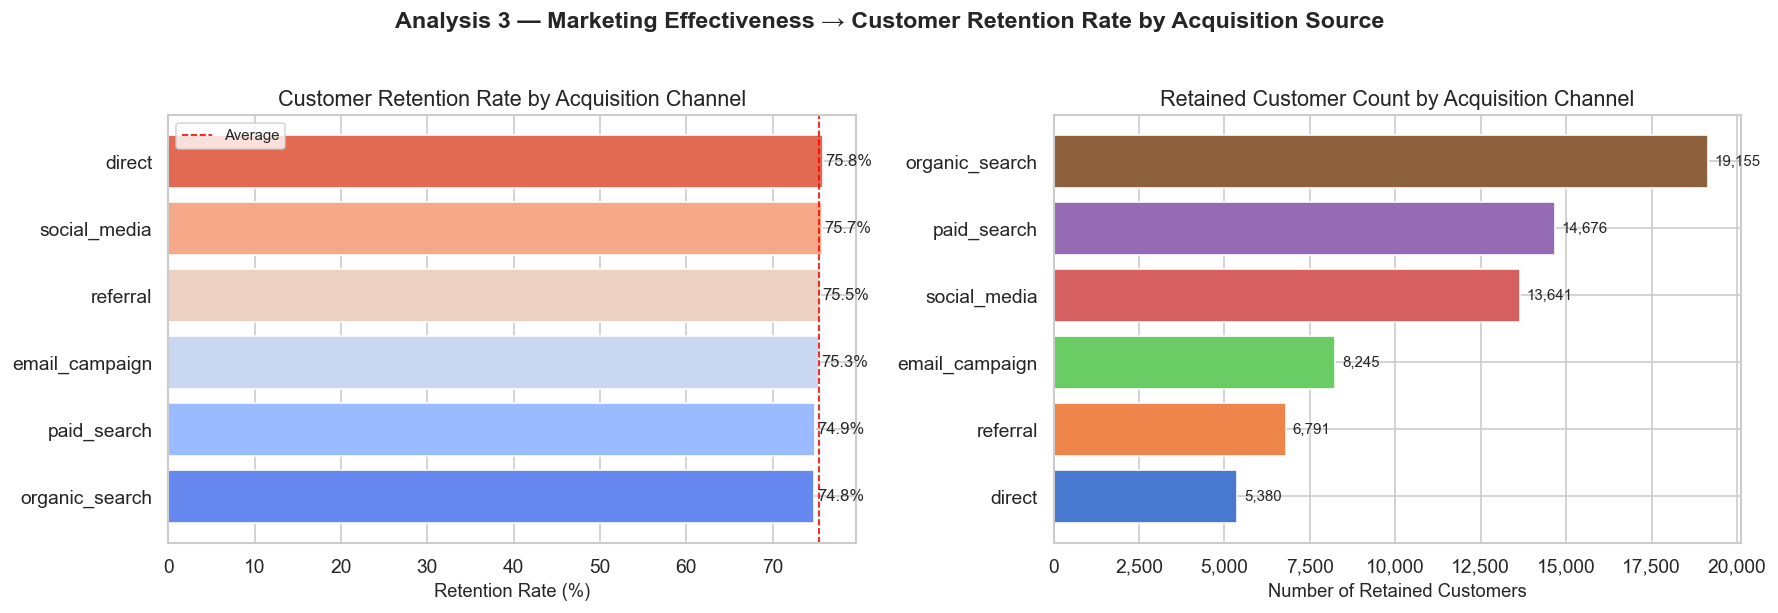


── Retention Rate by Acquisition Source ────────────────────────────────
acquisition_source  total_customers  retained_customers  retention_rate_pct
            direct             7096                5380               75.82
      social_media            18016               13641               75.72
          referral             8995                6791               75.50
    email_campaign            10943                8245               75.34
       paid_search            19600               14676               74.88
    organic_search            25596               19155               74.84


In [91]:
# ══════════════════════════════════════════════════════════════════════════
# ANALYSIS 3 — Marketing Effectiveness → Retention Rate by Acquisition Source
#
# Logic:
#   - The order_source of a customer's FIRST order is their "acquisition channel"
#   - A customer is "retained" if they placed at least one subsequent order
#   - Retention rate = retained customers / total customers acquired per channel
# ══════════════════════════════════════════════════════════════════════════

# One row per customer: acquisition source = order_source of their rank-1 order
first_orders = (
    order_level[order_level['order_rank'] == 1]
    [['customer_id', 'order_source']]
    .rename(columns={'order_source': 'acquisition_source'})
)

# Total number of orders each customer ever placed
cust_order_count = (
    order_level.groupby('customer_id', as_index=False)['order_id']
    .count()
    .rename(columns={'order_id': 'total_orders'})
)

first_orders = first_orders.merge(cust_order_count, on='customer_id')
first_orders['is_retained'] = first_orders['total_orders'] > 1

retention_by_src = (
    first_orders.groupby('acquisition_source', as_index=False)
    .agg(
        total_customers    = ('customer_id', 'count'),
        retained_customers = ('is_retained', 'sum'),
    )
)
retention_by_src['retention_rate_pct'] = (
    retention_by_src['retained_customers'] / retention_by_src['total_customers'] * 100
)
# Sort ascending so highest retention rate appears at top in barh
retention_by_src = retention_by_src.sort_values('retention_rate_pct', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Analysis 3 — Marketing Effectiveness → Customer Retention Rate by Acquisition Source',
             fontsize=14, fontweight='bold', y=1.02)

pal3 = sns.color_palette('coolwarm', len(retention_by_src))

# (a) Retention rate % — largest at top
bars = axes[0].barh(
    retention_by_src['acquisition_source'],
    retention_by_src['retention_rate_pct'],
    color=pal3, edgecolor='white'
)
for bar, val in zip(bars, retention_by_src['retention_rate_pct']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=10)
axes[0].set_xlabel('Retention Rate (%)')
axes[0].set_title('Customer Retention Rate by Acquisition Channel')
axes[0].axvline(retention_by_src['retention_rate_pct'].mean(),
                color='red', linestyle='--', linewidth=1, label='Average')
axes[0].legend(fontsize=9)

# (b) Absolute count of retained customers — sorted largest at top
ret_abs = retention_by_src.sort_values('retained_customers', ascending=True)
bars2 = axes[1].barh(
    ret_abs['acquisition_source'],
    ret_abs['retained_customers'],
    color=sns.color_palette('muted', len(ret_abs)), edgecolor='white'
)
for bar, val in zip(bars2, ret_abs['retained_customers']):
    axes[1].text(bar.get_width() + ret_abs['retained_customers'].max() * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=9)
axes[1].set_xlabel('Number of Retained Customers')
axes[1].set_title('Retained Customer Count by Acquisition Channel')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

print("\n── Retention Rate by Acquisition Source ────────────────────────────────")
print(retention_by_src.sort_values('retention_rate_pct', ascending=False)
      [['acquisition_source', 'total_customers', 'retained_customers', 'retention_rate_pct']]
      .to_string(index=False))

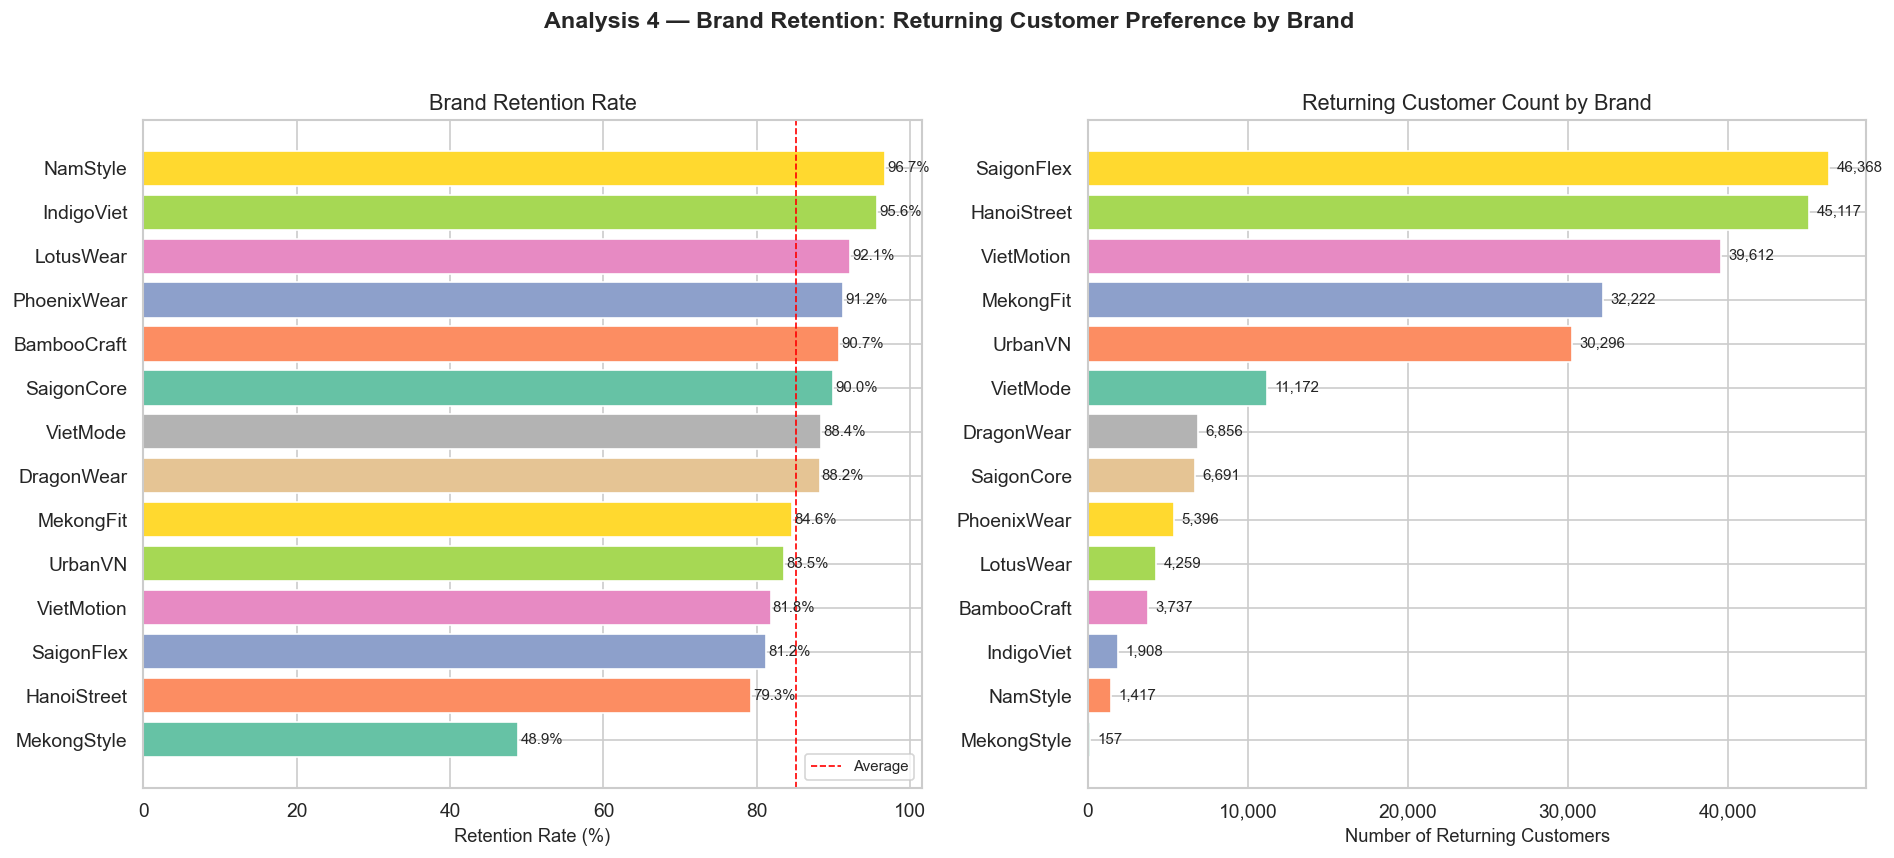


── Brand Retention Summary ──────────────────────────────────────────────
      brand  total_customers  repeat_customers  repeat_orders  brand_retention_rate_pct
   NamStyle             1466              1417           1507                     96.66
 IndigoViet             1995              1908           1970                     95.64
  LotusWear             4623              4259           4903                     92.13
PhoenixWear             5914              5396           6085                     91.24
BambooCraft             4118              3737           4089                     90.75
 SaigonCore             7438              6691           8731                     89.96
   VietMode            12637             11172          17054                     88.41
 DragonWear             7776              6856           8452                     88.17
  MekongFit            38108             32222          64623                     84.55
    UrbanVN            36282             3029

In [92]:
# ══════════════════════════════════════════════════════════════════════════
# ANALYSIS 4 — Brand Retention: Which Brand Do Returning Customers Prefer?
#
# Metric: brand retention rate =
#   customers who purchased brand B in a repeat order (rank ≥ 2)
#   ÷ all customers who ever purchased brand B (any rank)
# ══════════════════════════════════════════════════════════════════════════

brand_repeat = (
    repeat_items.groupby('brand', as_index=False)
    .agg(
        repeat_orders    = ('order_id',    'nunique'),
        repeat_customers = ('customer_id', 'nunique'),
    )
)

brand_total_cust = (
    master_with_rank.groupby('brand', as_index=False)['customer_id']
    .nunique()
    .rename(columns={'customer_id': 'total_customers'})
)
brand_repeat = brand_repeat.merge(brand_total_cust, on='brand')
brand_repeat['brand_retention_rate_pct'] = (
    brand_repeat['repeat_customers'] / brand_repeat['total_customers'] * 100
)
# Sort ascending so highest rate appears at top in barh
brand_repeat = brand_repeat.sort_values('brand_retention_rate_pct', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Analysis 4 — Brand Retention: Returning Customer Preference by Brand',
             fontsize=14, fontweight='bold', y=1.02)

pal4 = sns.color_palette('Set2', len(brand_repeat))

# (a) Retention rate by brand — highest at top
bars = axes[0].barh(
    brand_repeat['brand'],
    brand_repeat['brand_retention_rate_pct'],
    color=pal4, edgecolor='white'
)
for bar, val in zip(bars, brand_repeat['brand_retention_rate_pct']):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=9)
axes[0].set_xlabel('Retention Rate (%)')
axes[0].set_title('Brand Retention Rate')
axes[0].axvline(brand_repeat['brand_retention_rate_pct'].mean(),
                color='red', linestyle='--', linewidth=1, label='Average')
axes[0].legend(fontsize=9)

# (b) Absolute repeat customers by brand — highest at top
brand_abs = brand_repeat.sort_values('repeat_customers', ascending=True)
bars2 = axes[1].barh(
    brand_abs['brand'],
    brand_abs['repeat_customers'],
    color=pal4, edgecolor='white'
)
for bar, val in zip(bars2, brand_abs['repeat_customers']):
    axes[1].text(bar.get_width() + brand_abs['repeat_customers'].max() * 0.01,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=9)
axes[1].set_xlabel('Number of Returning Customers')
axes[1].set_title('Returning Customer Count by Brand')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

print("\n── Brand Retention Summary ──────────────────────────────────────────────")
print(brand_repeat.sort_values('brand_retention_rate_pct', ascending=False)
      [['brand', 'total_customers', 'repeat_customers',
        'repeat_orders', 'brand_retention_rate_pct']]
      .to_string(index=False))

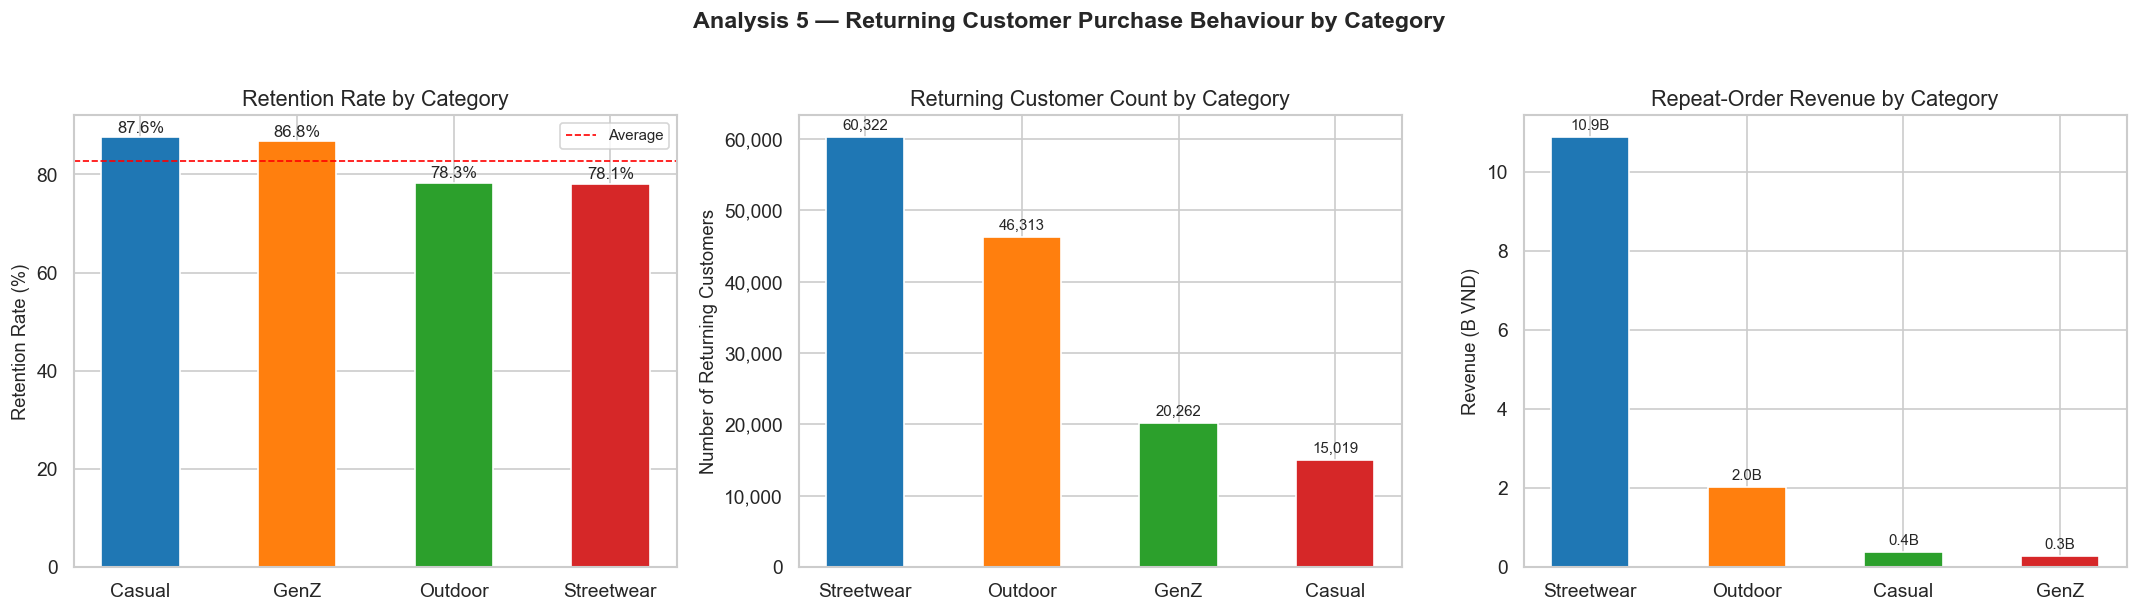


── Category Retention Summary ───────────────────────────────────────────
  category  total_customers  repeat_customers  repeat_orders    repeat_revenue  cat_retention_rate_pct
    Casual            17136             15019          21058    395,740,815.00                   87.65
      GenZ            23350             20262          32618    293,029,968.51                   86.78
   Outdoor            59121             46313         169176  2,017,772,432.94                   78.34
Streetwear            77215             60322         337348 10,891,492,835.47                   78.12


In [93]:
# ══════════════════════════════════════════════════════════════════════════
# ANALYSIS 5 — Which Categories Do Returning Customers Buy Most?
# ══════════════════════════════════════════════════════════════════════════

cat_repeat = (
    repeat_items.groupby('category', as_index=False)
    .agg(
        repeat_orders    = ('order_id',    'nunique'),
        repeat_customers = ('customer_id', 'nunique'),
        repeat_revenue   = ('line_revenue', 'sum'),
    )
)

cat_total_cust = (
    master_with_rank.groupby('category', as_index=False)['customer_id']
    .nunique()
    .rename(columns={'customer_id': 'total_customers'})
)
cat_repeat = cat_repeat.merge(cat_total_cust, on='category')
# Retention rate = customers who bought category C in a repeat order /
#                  all customers who ever bought category C
cat_repeat['cat_retention_rate_pct'] = (
    cat_repeat['repeat_customers'] / cat_repeat['total_customers'] * 100
)
cat_repeat = cat_repeat.sort_values('cat_retention_rate_pct', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Analysis 5 — Returning Customer Purchase Behaviour by Category',
             fontsize=14, fontweight='bold', y=1.02)

pal5 = sns.color_palette('tab10', len(cat_repeat))

# (a) Retention rate by category
bars = axes[0].bar(
    cat_repeat['category'],
    cat_repeat['cat_retention_rate_pct'],
    color=pal5, edgecolor='white', width=0.5
)
for bar, val in zip(bars, cat_repeat['cat_retention_rate_pct']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3, f'{val:.1f}%',
                 ha='center', va='bottom', fontsize=10)
axes[0].set_ylabel('Retention Rate (%)')
axes[0].set_title('Retention Rate by Category')
axes[0].axhline(cat_repeat['cat_retention_rate_pct'].mean(),
                color='red', linestyle='--', linewidth=1, label='Average')
axes[0].legend(fontsize=9)

# (b) Absolute repeat customers count
cat_abs = cat_repeat.sort_values('repeat_customers', ascending=False)
bars2 = axes[1].bar(
    cat_abs['category'],
    cat_abs['repeat_customers'],
    color=pal5, edgecolor='white', width=0.5
)
for bar, val in zip(bars2, cat_abs['repeat_customers']):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + cat_abs['repeat_customers'].max() * 0.01,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('Number of Returning Customers')
axes[1].set_title('Returning Customer Count by Category')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# (c) Revenue from repeat orders by category
cat_rev = cat_repeat.sort_values('repeat_revenue', ascending=False)
bars3 = axes[2].bar(
    cat_rev['category'],
    cat_rev['repeat_revenue'] / 1e9,
    color=pal5, edgecolor='white', width=0.5
)
for bar, val in zip(bars3, cat_rev['repeat_revenue']):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + cat_rev['repeat_revenue'].max() / 1e9 * 0.01,
                 f'{val/1e9:.1f}B', ha='center', va='bottom', fontsize=9)
axes[2].set_ylabel('Revenue (B VND)')
axes[2].set_title('Repeat-Order Revenue by Category')
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

print("\n── Category Retention Summary ───────────────────────────────────────────")
print(cat_repeat[['category', 'total_customers', 'repeat_customers',
                   'repeat_orders', 'repeat_revenue', 'cat_retention_rate_pct']]
      .sort_values('cat_retention_rate_pct', ascending=False)
      .to_string(index=False))